#### 1- Préparation

In [1]:
# Chargement des librairies
import pandas as pd

In [2]:
# Chargement des données
data = pd.read_csv('data/dataset_malware.csv')

#### 2- Exploration des données - Exploratory Data Analysis (EDA)
Ici, on se pose des questions sur le jeu de données.

In [3]:
# Combiend a-t-on de lignes et de colonnes au total ?
data.shape

(19611, 79)

In [4]:
# à quoi ressemble le jeu de données ?
data.head()

,Name,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,...,SectionMaxChar,SectionMainChar,DirectoryEntryImport,DirectoryEntryImportSize,DirectoryEntryExport,ImageDirectoryEntryExport,ImageDirectoryEntryImport,ImageDirectoryEntryResource,ImageDirectoryEntryException,ImageDirectoryEntrySecurity
0,VirusShare_a878ba26000edaac5c98eff4432723b3,23117,144,3,0,4,0,65535,0,184,...,3758096608,0,7,152,0,0,54440,77824,73728,0
1,VirusShare_ef9130570fddc174b312b2047f5f4cf0,23117,144,3,0,4,0,65535,0,184,...,3791650880,0,16,311,0,0,262276,294912,0,346112
2,VirusShare_ef84cdeba22be72a69b198213dada81a,23117,144,3,0,4,0,65535,0,184,...,3221225536,0,6,176,0,0,36864,40960,0,0
3,VirusShare_6bf3608e60ebc16cbcff6ed5467d469e,23117,144,3,0,4,0,65535,0,184,...,3224371328,0,8,155,0,0,356352,1003520,0,14109472
4,VirusShare_2cc94d952b2efb13c7d6bbe0dd59d3fb,23117,144,3,0,4,0,65535,0,184,...,3227516992,0,2,43,0,0,61440,73728,0,90624


In [5]:
# Quels sont les noms des colonnes ?
data.columns.sort_values()

Index(['AddressOfEntryPoint', 'BaseOfCode', 'Characteristics', 'CheckSum',
       'DirectoryEntryExport', 'DirectoryEntryImport',
       'DirectoryEntryImportSize', 'DllCharacteristics', 'FileAlignment',
       'ImageBase', 'ImageDirectoryEntryException',
       'ImageDirectoryEntryExport', 'ImageDirectoryEntryImport',
       'ImageDirectoryEntryResource', 'ImageDirectoryEntrySecurity',
       'LoaderFlags', 'Machine', 'Magic', 'MajorImageVersion',
       'MajorLinkerVersion', 'MajorOperatingSystemVersion',
       'MajorSubsystemVersion', 'Malware', 'MinorImageVersion',
       'MinorLinkerVersion', 'MinorOperatingSystemVersion',
       'MinorSubsystemVersion', 'Name', 'NumberOfRvaAndSizes',
       'NumberOfSections', 'NumberOfSymbols', 'PointerToSymbolTable',
       'SectionAlignment', 'SectionMainChar', 'SectionMaxChar',
       'SectionMaxEntropy', 'SectionMaxPhysical', 'SectionMaxPointerData',
       'SectionMaxRawsize', 'SectionMaxVirtual', 'SectionMaxVirtualsize',
       'SectionMi

In [6]:
# Combien de valeurs manquantes dans le jeu de données ?
data.isna().sum() # par colonne
data.isna().sum().sum() # Au total

np.int64(0)

In [7]:
# Combien de valeurs uniques a la colonne cible ?
data.Malware.unique()

array([1, 0])

<Axes: title={'center': 'Distribution de la variable cible'}, xlabel='Malware', ylabel='Count'>

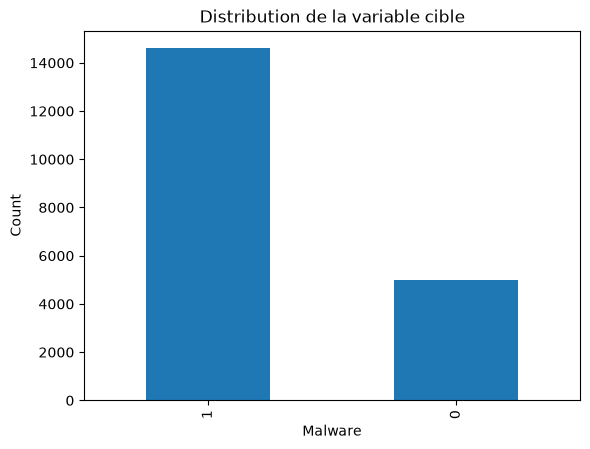

In [9]:
data.Malware.value_counts().plot(kind='bar', title='Distribution de la variable cible', xlabel='Malware', ylabel='Count')

#### 3- Préparation des données - Data preprocessing

In [10]:
# A-t-on des colonnes non numériques dans le jeu de données ?
data.dtypes.value_counts()

int64      77
str         1
float64     1
Name: count, dtype: int64

In [12]:
data.select_dtypes(include=['str'])

,Name
0,VirusShare_a878ba26000edaac5c98eff4432723b3
1,VirusShare_ef9130570fddc174b312b2047f5f4cf0
2,VirusShare_ef84cdeba22be72a69b198213dada81a
3,VirusShare_6bf3608e60ebc16cbcff6ed5467d469e
4,VirusShare_2cc94d952b2efb13c7d6bbe0dd59d3fb
...,...
19606,clip.exe
19607,VNC-Server-6.2.0-Windows.exe
19608,Microsoft.GroupPolicy.Management.ni.dll
19609,cryptuiwizard.dll


In [13]:
#On ne veux pas garder la colone nom car on ne veut pas entrainer notre modèle là-dessus
data.drop(['Name'], axis=1, inplace=True)

In [14]:
# base method : label encoding
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# for column in data:
#     data[column] = le.fit_transform(data[column])

ModuleNotFoundError: No module named 'sklearn'

In [24]:
features = data.drop(['Malware'], axis=1) # On supprime la colonne malware et on envoie la table dans feature
labels = data['Malware'] # On extrait 

In [32]:
from sklearn.model_selection import train_test_split
train_features,test_features,train_labels,test_labels = train_test_split(features,labels,test_size = 0.2,random_state = 42) # random_state c'est la seed


#### 3- Data processing

### Description des modèles disponibles

#### 1. KNeighborsClassifier (KNN) modèle de densité

Le KNN classe un fichier en observant les `K` exemples les plus proches dans le jeu de données.
Il est simple à comprendre, mais peut devenir lent lorsque le nombre de données est important.


#### 2. LogisticRegression

La régression logistique sépare les classes à l'aide d'une frontière linéaire.
Elle est rapide et relativement facile à interpréter, mais elle fonctionne mieux lorsque les données sont standardisées.


#### 3. DecisionTreeClassifier

L'arbre de décision crée une suite de règles pour classer les fichiers.
Il est facile à visualiser et à expliquer, mais il peut facilement faire du surapprentissage.


#### 4. RandomForestClassifier

La forêt aléatoire combine plusieurs arbres de décision et agrège leurs prédictions.
Elle est généralement robuste sur les données tabulaires, détecte les relations non linéaires et limite le surapprentissage par rapport à un arbre seul.


#### 5. SVC

Le Support Vector Classifier cherche la frontière qui sépare au mieux les classes.
Il peut être très performant, mais son entraînement peut être coûteux sur un grand jeu de données.


#### 6. GaussianNB

Gaussian Naive Bayes utilise les probabilités pour classer les observations.
Il est très rapide, mais suppose que les variables suivent une distribution gaussienne et que les caractéristiques sont relativement indépendantes.


### Quel est le meilleur modèle ?

Pour ce jeu de données tabulaire, **RandomForestClassifier est un bon candidat** car il :

- gère les relations non linéaires ;
- fonctionne généralement bien avec des données tabulaires ;
- est plus robuste qu'un arbre de décision seul ;
- nécessite moins de standardisation que la régression logistique ou le SVC.


Cependant, on ne peut pas déclarer un modèle meilleur sans les tester dans les mêmes conditions. Il faut comparer :

- l'accuracy ;
- le rappel de la classe `Malware` ;
- le nombre de faux négatifs ;
- le temps d'entraînement et de prédiction.


En cybersécurité, le critère prioritaire est souvent le nombre de **faux négatifs** : ce sont les malwares classés à tort comme fichiers bénins. Le meilleur modèle sera donc celui qui détecte le plus de malwares tout en conservant un nombre acceptable de faux positifs.

In [56]:
# Model Training
#from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.naive_bayes import GaussianNB

classifier = LogisticRegression(max_iter=1000)
classifier = classifier.fit(train_features, train_labels)

c:\Users\Lucas\8IAR805---Cybersecurity-AI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [57]:
predicted_labels = classifier.predict(test_features)
predicted_labels

array([1, 1, 1, ..., 0, 1, 1], shape=(3923,))

In [58]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(test_labels, predicted_labels)
accuracy

0.9166454244200867

In [59]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, predicted_labels)
cm

array([[ 757,  209],
       [ 118, 2839]])

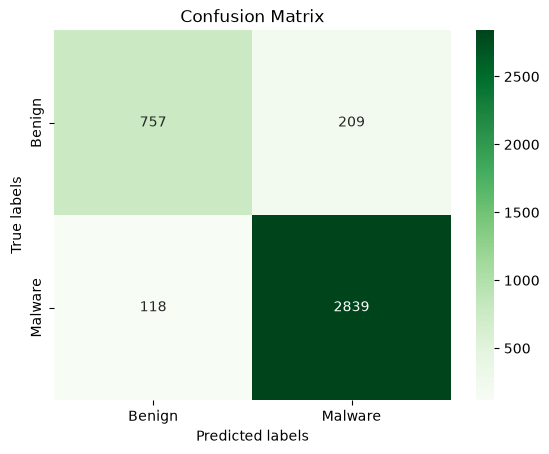

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = plt.subplot()
sns.heatmap(cm, annot=True, ax = ax, fmt='g', cmap='Greens'); #annot=True to annotate cells

# labels, title and ticks
ax.set_xlabel('Predicted labels');
ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(['Benign', 'Malware']); 
ax.yaxis.set_ticklabels(['Benign', 'Malware']);

# Verdict : 
Taille de jeu de données : 6.7 Mo en format csv.

Modèle : KNN avec K = 5

Accuracy : 96.78817231710426%
Besoin : 77 colonnes.

Temps d'exécution : 27 secondes pour 19611 prédictions, soit 1.3767783 millisecondes par prédiction.

Pouvoir explicatif : fort nativement. Un fichier est classifié comme virus si les 5 plus proches lignes sont majoritairement des virus (min. 3 sur 5).



# À faire : 
1. Exécutez le même code. Avez-vous eu le même résultats que moi? Accuracy ou temps d'exécution.

2. Si vous changez K, pouvez-vous faire mieux? Accuracy ou temps d'exécution.

3. Si vous changez KNN avec un autre modèle, pouvez-vous faire mieux? Accuracy ou temps d'exécution.
    - Pour vous aider, voici d'autres modèles possibles :
        - from sklearn.linear_model import LogisticRegression
        - from sklearn.tree import DecisionTreeClassifier
        - from sklearn.ensemble import RandomForestClassifier
        - from sklearn.svm import SVC
        - from sklearn.naive_bayes import GaussianNB
    - La liste complète est sur le site de scikit-learn : https://scikit-learn.org/stable/supervised_learning.html